# World Happiness Report Analysis
**Goal:** Explore socio-economic indicators and their impact on Happiness Score across countries.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [14]:
import os
os.getcwd()

'C:\\Users\\rames\\my-first-project'

In [26]:
import os

# List all files in the data folder
os.listdir("data")

['netflix_titles.csv', 'world_happiness_2024.csv.csv']

In [28]:
import pandas as pd

df = pd.read_csv("data/world_happiness_2024.csv")
df.head()  # check first 5 rows

,Country name,Regional indicator,Ladder score,upperwhisker,lowerwhisker,Log GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption,Dystopia + residual
0,Finland,Western Europe,7.741,7.815,7.667,1.844,1.572,0.695,0.859,0.142,0.546,2.082
1,Denmark,Western Europe,7.583,7.665,7.500,1.908,1.520,0.699,0.823,0.204,0.548,1.881
2,Iceland,Western Europe,7.525,7.618,7.433,1.881,1.617,0.718,0.819,0.258,0.182,2.050
3,Sweden,Western Europe,7.344,7.422,7.267,1.878,1.501,0.724,0.838,0.221,0.524,1.658
4,Israel,Middle East and North Africa,7.341,7.405,7.277,1.803,1.513,0.740,0.641,0.153,0.193,2.298


In [30]:
# Check column names and data types
df.info()

# Summary statistics
df.describe()

# Check missing values
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143 entries, 0 to 142
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country name                  143 non-null    object 
 1   Regional indicator            143 non-null    object 
 2   Ladder score                  143 non-null    float64
 3   upperwhisker                  143 non-null    float64
 4   lowerwhisker                  143 non-null    float64
 5   Log GDP per capita            140 non-null    float64
 6   Social support                140 non-null    float64
 7   Healthy life expectancy       140 non-null    float64
 8   Freedom to make life choices  140 non-null    float64
 9   Generosity                    140 non-null    float64
 10  Perceptions of corruption     140 non-null    float64
 11  Dystopia + residual           140 non-null    float64
dtypes: float64(10), object(2)
memory usage: 13.5+ KB


Country name                    0
Regional indicator              0
Ladder score                    0
upperwhisker                    0
lowerwhisker                    0
Log GDP per capita              3
Social support                  3
Healthy life expectancy         3
Freedom to make life choices    3
Generosity                      3
Perceptions of corruption       3
Dystopia + residual             3
dtype: int64

In [34]:
df.columns

Index(['Country name', 'Regional indicator', 'Ladder score', 'upperwhisker',
       'lowerwhisker', 'Log GDP per capita', 'Social support',
       'Healthy life expectancy', 'Freedom to make life choices', 'Generosity',
       'Perceptions of corruption', 'Dystopia + residual'],
      dtype='object')

<Figure size 1000x600 with 0 Axes>

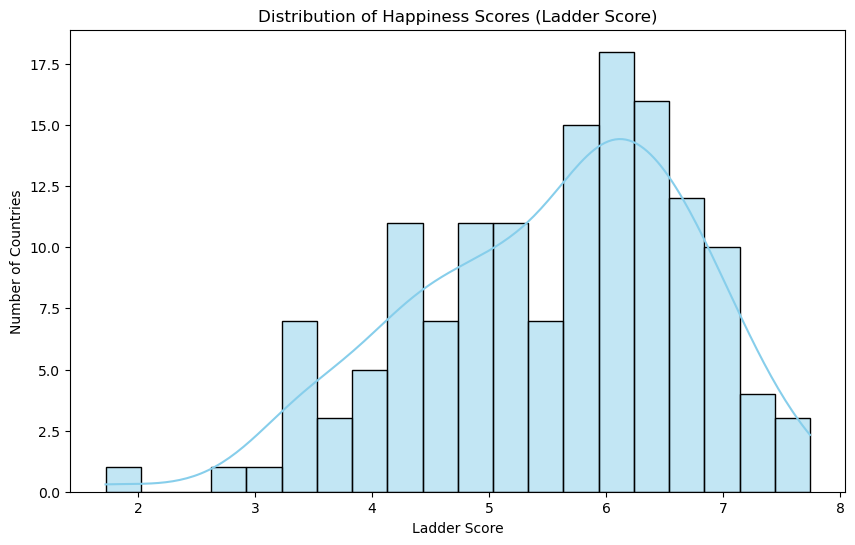

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.histplot(df['Ladder score'], bins=20, kde=True, color='skyblue')
plt.title("Distribution of Happiness Scores (Ladder Score)")
plt.xlabel("Ladder Score")
plt.ylabel("Number of Countries")
plt.show()

C:\Users\rames\AppData\Local\Temp\ipykernel_8096\2656531670.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ladder score', y='Country name', data=top10, palette='viridis')


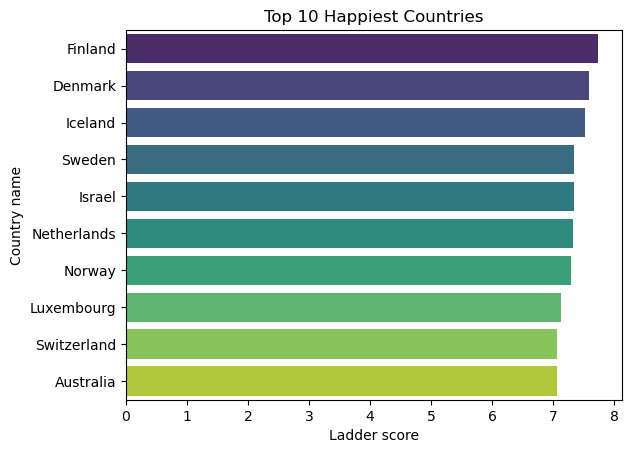

In [40]:
top10 = df.nlargest(10, 'Ladder score')
sns.barplot(x='Ladder score', y='Country name', data=top10, palette='viridis')
plt.title("Top 10 Happiest Countries")
plt.show()

C:\Users\rames\AppData\Local\Temp\ipykernel_8096\1643416114.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Ladder score', y='Country name', data=bottom10, palette='magma')


<Figure size 1000x800 with 0 Axes>

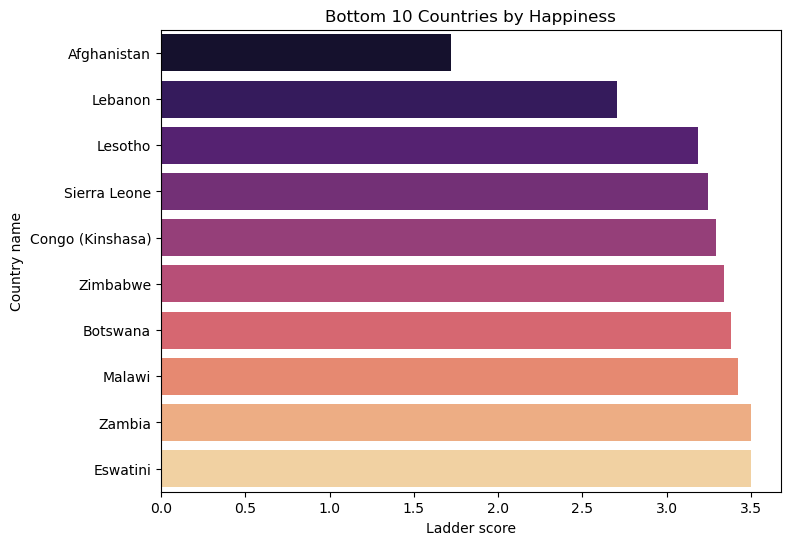

In [44]:
bottom10 = df.nsmallest(10, 'Ladder score')
plt.figure(figsize=(8,6))
sns.barplot(x='Ladder score', y='Country name', data=bottom10, palette='magma')
plt.title("Bottom 10 Countries by Happiness")
plt.show()

<Figure size 1200x1000 with 0 Axes>

<Figure size 1200x1000 with 0 Axes>

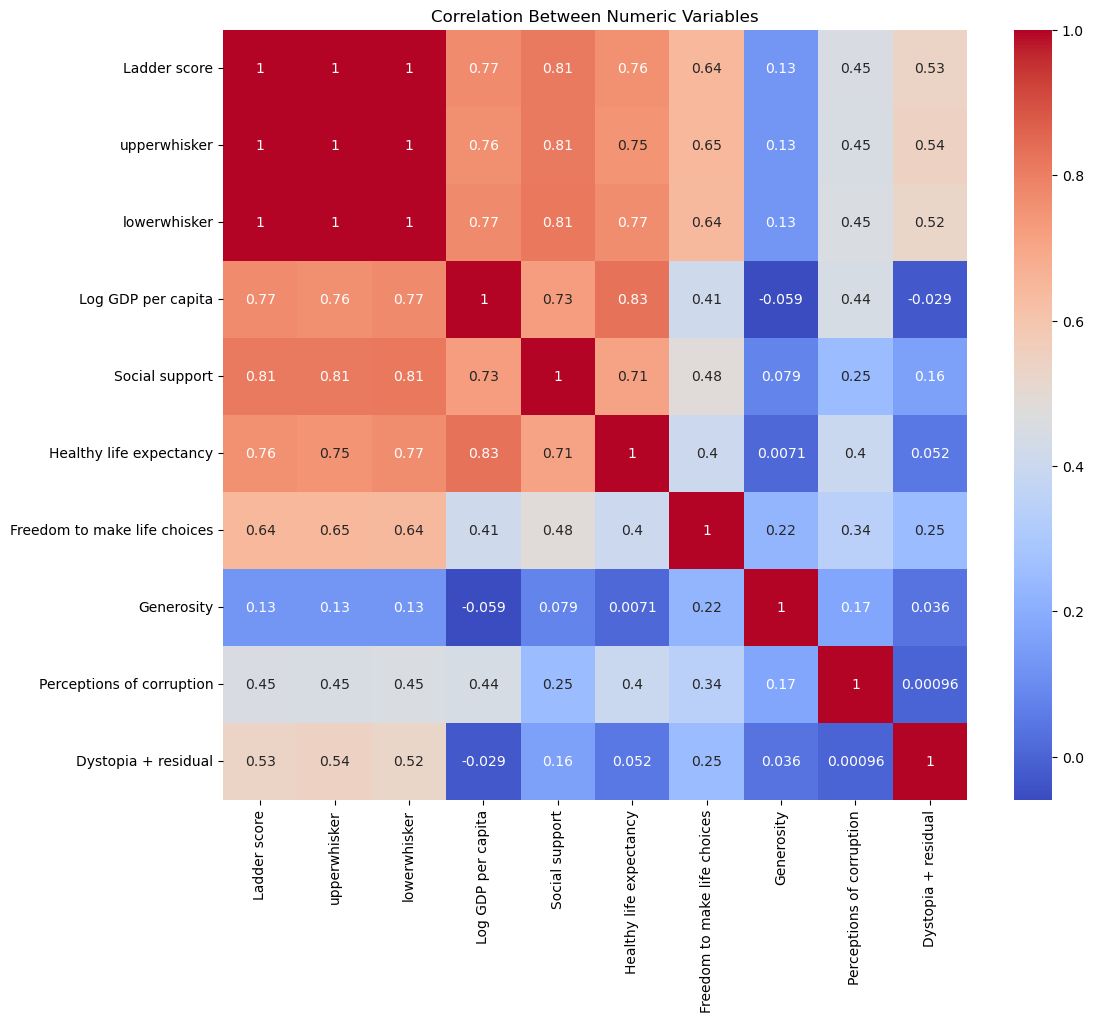

In [50]:
# Select only numeric columns
numeric_df = df.select_dtypes(include='number')

# Correlation heatmap
plt.figure(figsize=(12,10))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numeric Variables")
plt.show()

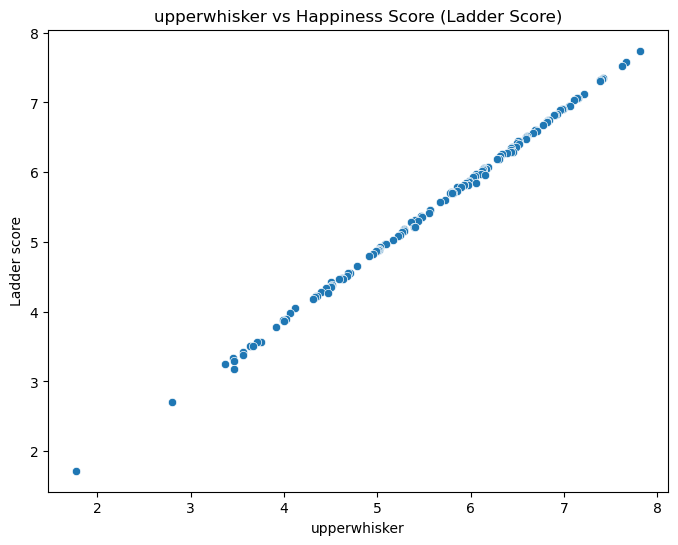

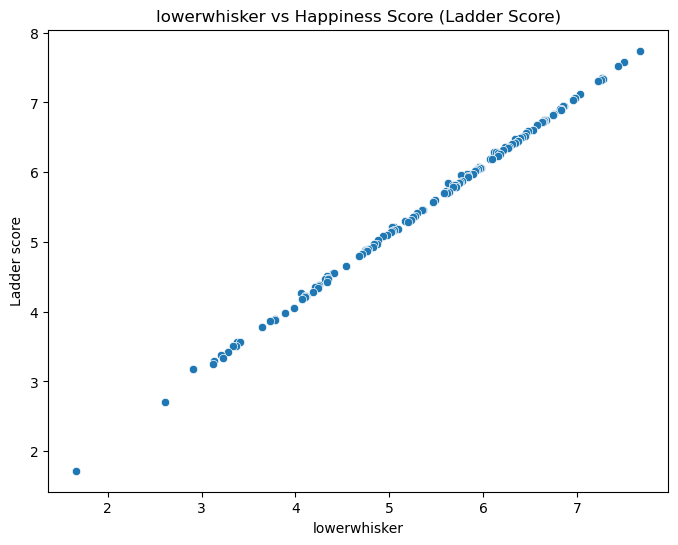

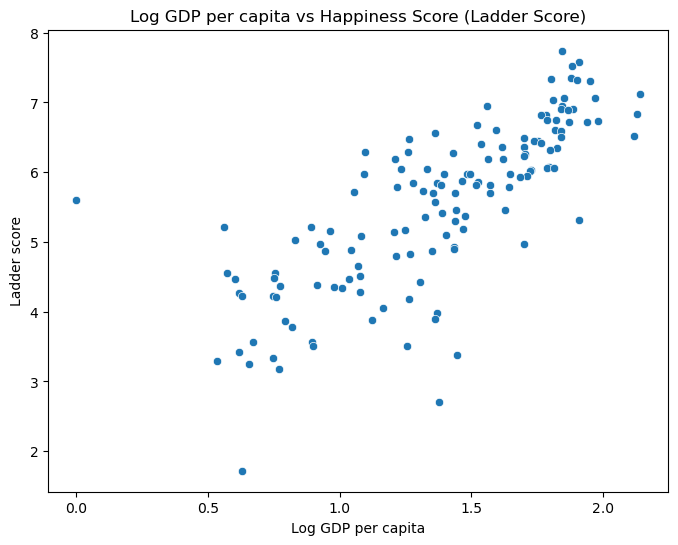

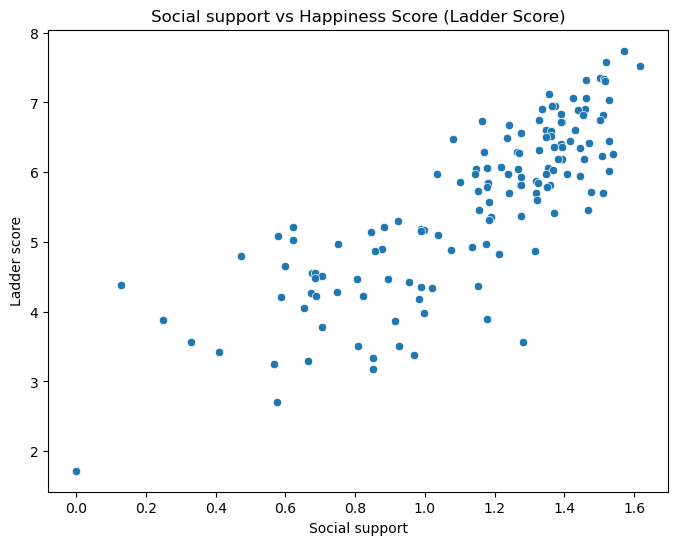

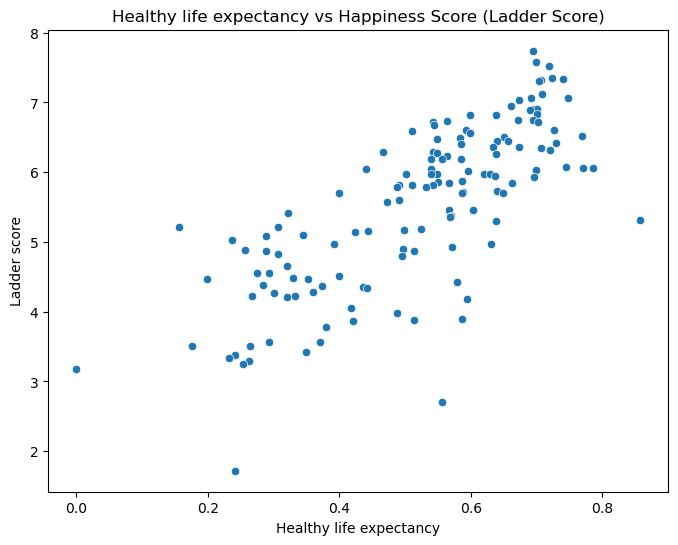

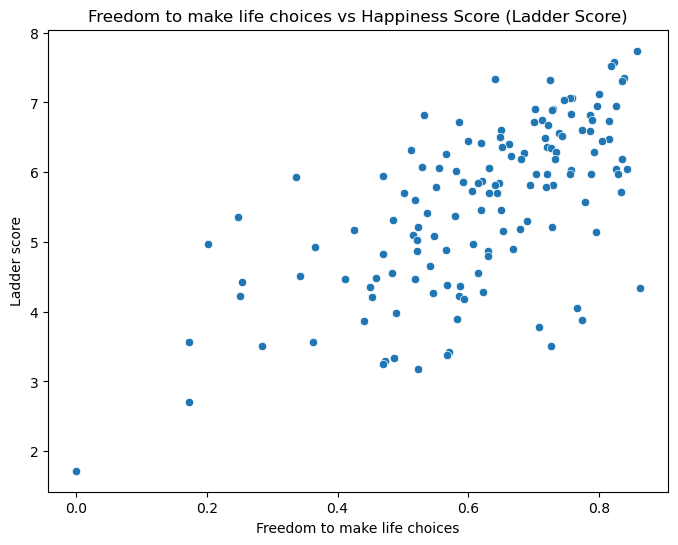

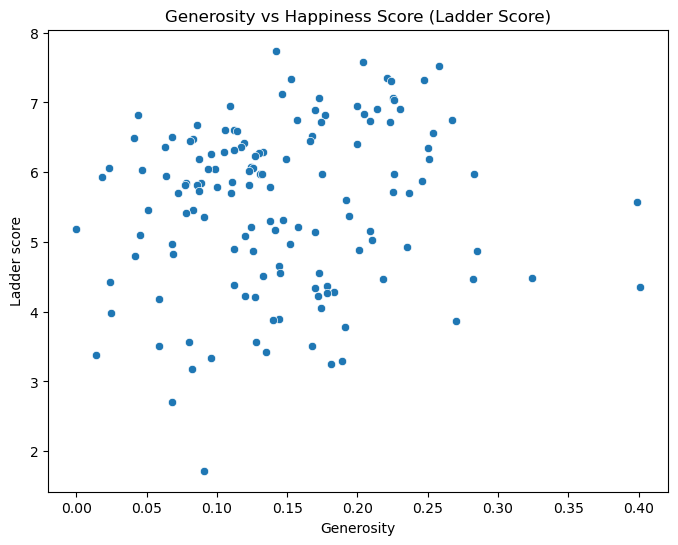

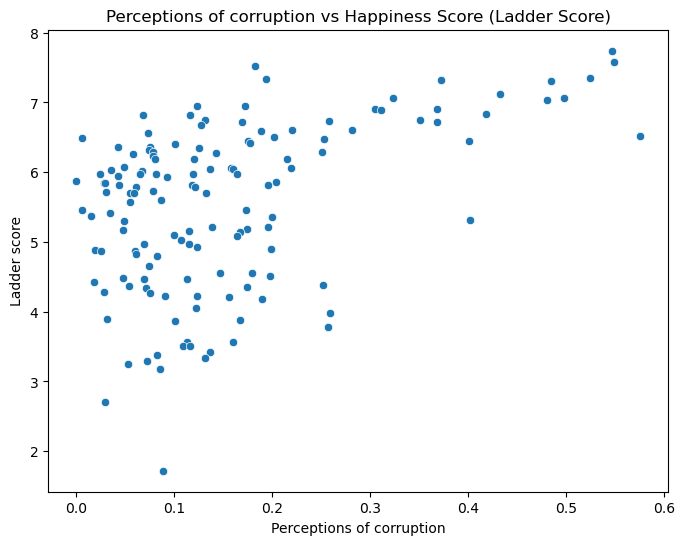

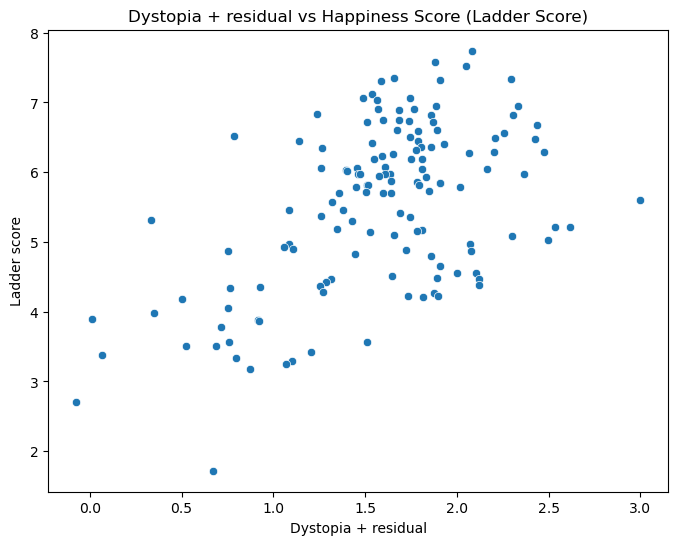

In [52]:
# Automatically pick numeric columns excluding Ladder score for scatter plots
factors = numeric_df.columns.drop('Ladder score')

for col in factors:
    plt.figure(figsize=(8,6))
    sns.scatterplot(x=col, y='Ladder score', data=df)
    plt.title(f"{col} vs Happiness Score (Ladder Score)")
    plt.show()

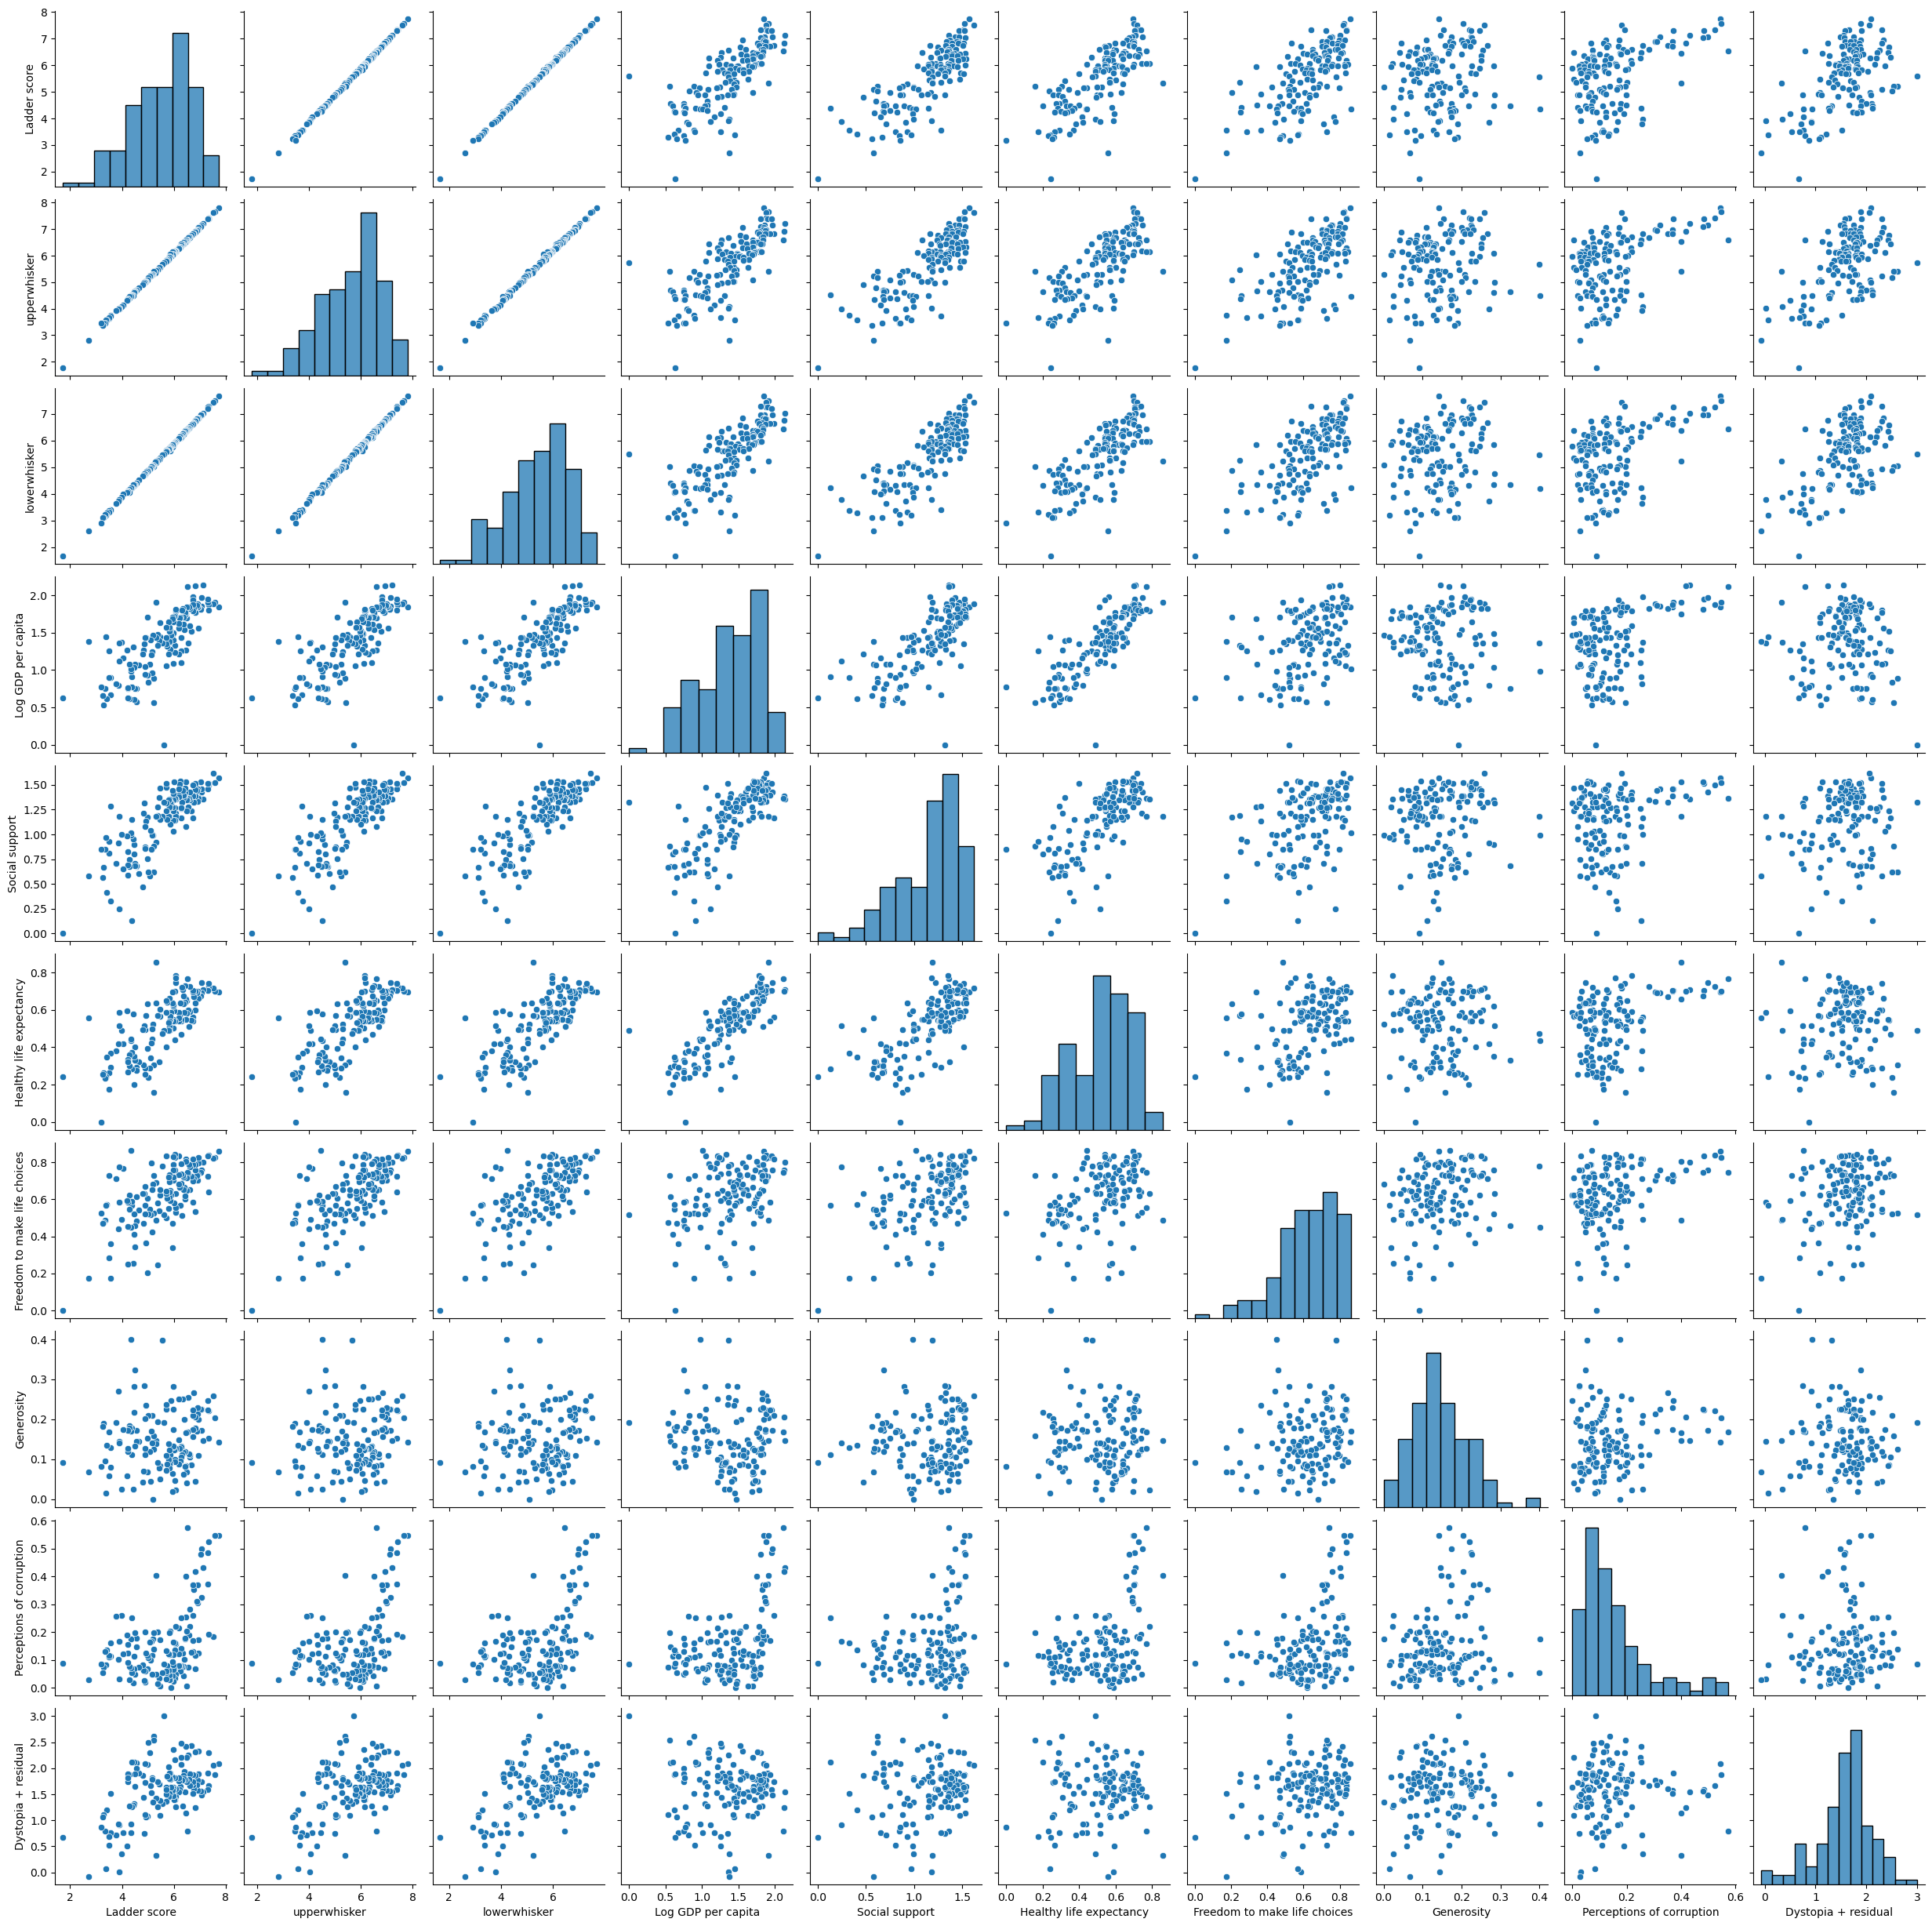

In [54]:
# Only numeric columns
sns.pairplot(numeric_df)
plt.show()